In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#load in our data

airbnb = pd.read_csv("/Users/juliagallucci/Desktop/CI:TA Positions/DSI Linear regression, classification, and resampling CI/LCR/01_materials/notebooks/dataset/listings.csv")

In [3]:
airbnb

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
0,1.318800e+04,Riley Park,Entire home/apt,4,1.0,0.0,2.0,14
1,1.335800e+04,Downtown,Entire home/apt,2,1.0,1.0,1.0,20
2,1.349000e+04,Kensington-Cedar Cottage,Entire home/apt,2,1.0,1.0,1.0,35
3,1.426700e+04,Kensington-Cedar Cottage,Entire home/apt,4,1.0,1.0,2.0,35
4,1.625400e+04,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,3.0,36
...,...,...,...,...,...,...,...,...
4981,9.970000e+17,Downtown,Entire home/apt,4,1.0,1.0,2.0,3000
4982,9.970000e+17,South Cambie,Entire home/apt,4,NaN,2.0,NaN,5714
4983,9.970000e+17,South Cambie,Private room,2,1.0,1.0,0.0,8495
4984,9.970000e+17,Downtown,Entire home/apt,4,NaN,2.0,NaN,9600


In [ ]:
airbnb["price"].mean() #population parameter
#this is usually unknown 

np.float64(249.16526273565984)

In [17]:
#np.random.seed(100)

airbnb.sample(n= 40)["price"].mean() #point estimate

np.float64(216.775)

In [18]:
sample_list = [] #initialize an empty list

for i in range(20_000):
    sample = airbnb.sample(n=40)
    sample = sample.assign(replicate = i)
    sample_list.append(sample)

In [19]:
samples = pd.concat(sample_list)
samples

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
189,3.857478e+06,West End,Entire home/apt,3,1.0,1.0,2.0,65,0
1068,2.475608e+07,Kitsilano,Entire home/apt,2,1.0,1.0,1.0,120,0
4743,9.610000e+17,Downtown,Entire home/apt,6,2.0,2.0,0.0,595,0
1453,3.263148e+07,Riley Park,Entire home/apt,6,1.5,3.0,3.0,135,0
3296,6.900000e+17,Grandview-Woodland,Entire home/apt,6,2.5,2.0,2.0,249,0
...,...,...,...,...,...,...,...,...,...
1689,3.604614e+07,Renfrew-Collingwood,Entire home/apt,7,1.0,3.0,5.0,147,19999
677,1.794238e+07,Kitsilano,Entire home/apt,4,1.0,1.0,2.0,101,19999
360,8.423376e+06,Grandview-Woodland,Entire home/apt,4,NaN,11.0,NaN,79,19999
873,2.153251e+07,Downtown,Entire home/apt,6,1.0,1.0,2.0,111,19999


In [24]:
sample_estimates = samples.groupby("replicate")["price"].mean().reset_index(name = "sample_mean")

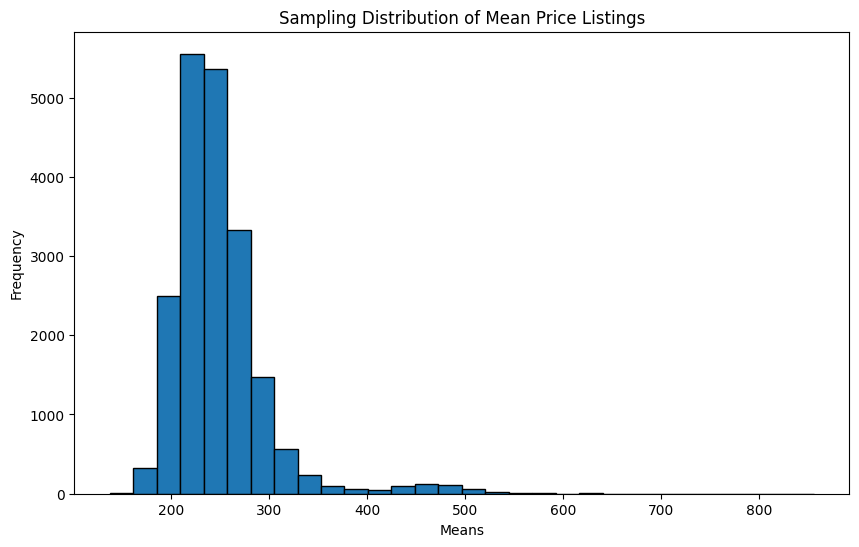

In [25]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimates['sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [40]:
#this is the only data we have
np.random.seed(1234)
one_sample = airbnb.sample(n=400)

In [41]:
one_sample

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
2912,5.970000e+17,Riley Park,Entire home/apt,9,3.0,4.0,5.0,214
787,1.986261e+07,Mount Pleasant,Entire home/apt,9,2.0,3.0,3.0,109
2696,5.333958e+07,Arbutus Ridge,Entire home/apt,3,1.0,1.0,0.0,200
3017,6.310000e+17,West End,Entire home/apt,2,1.0,1.0,0.0,223
1226,2.745958e+07,Downtown,Entire home/apt,1,NaN,1.0,NaN,126
...,...,...,...,...,...,...,...,...
3327,6.960000e+17,Downtown,Entire home/apt,2,1.0,0.0,1.0,250
4926,9.880000e+17,Downtown,Entire home/apt,2,NaN,1.0,NaN,999
2064,4.287410e+07,Kitsilano,Entire home/apt,2,NaN,NaN,NaN,163
2762,5.417700e+07,Downtown Eastside,Entire home/apt,2,1.0,1.0,1.0,203


In [42]:
one_sample["price"].mean() #sample estimate

np.float64(242.03)

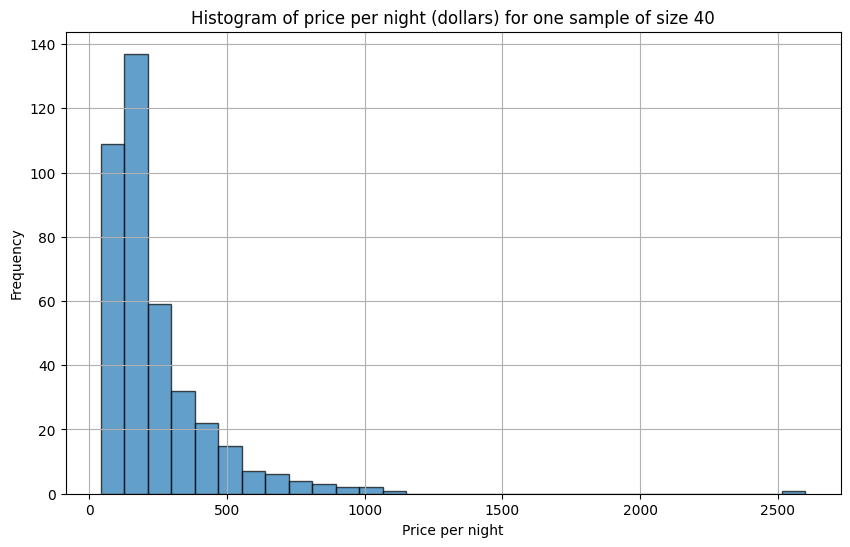

In [43]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()


In [44]:
#frac = 1; we want the sample to be the same size as the original
#replace = True; sample with replacement

boot1 = one_sample.sample(frac = 1, replace = True)

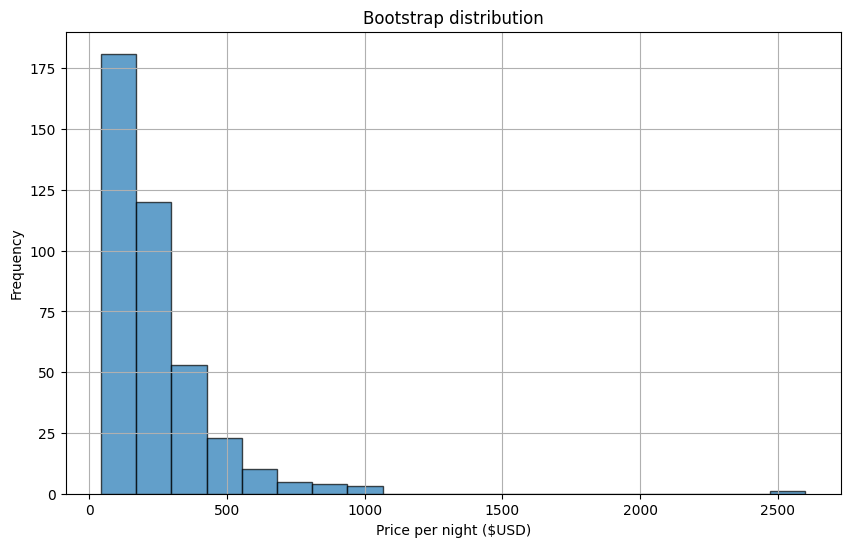

In [45]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()


In [46]:
bootstrap_samples = [] #initializing an empty list
for i in range(20_000): #20,000
    sample = one_sample.sample(frac=1, replace = True)
    sample = sample.assign(replicate = i)
    bootstrap_samples.append(sample)

In [47]:
boot20000 = pd.concat(bootstrap_samples)
boot20000

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
634,1.671988e+07,West Point Grey,Entire home/apt,9,3.0,3.0,4.0,100,0
181,3.678989e+06,Grandview-Woodland,Entire home/apt,4,1.0,1.0,2.0,63,0
4381,9.080000e+17,Downtown Eastside,Entire home/apt,4,NaN,2.0,NaN,400,0
1066,2.475420e+07,Kitsilano,Entire home/apt,2,1.0,1.0,1.0,120,0
1175,2.653210e+07,Killarney,Entire home/apt,5,1.0,3.0,3.0,125,0
...,...,...,...,...,...,...,...,...,...
2932,6.040000e+17,West End,Entire home/apt,2,1.0,1.0,1.0,215,19999
4824,9.700000e+17,Marpole,Entire home/apt,8,3.0,4.0,4.0,700,19999
3409,7.160000e+17,Marpole,Entire home/apt,2,1.0,1.0,1.0,254,19999
979,2.330587e+07,Riley Park,Entire home/apt,4,1.0,1.0,2.0,117,19999


In [48]:
boot_means = boot20000.groupby("replicate")["price"].mean().reset_index(name="mean_price")
boot_means

,replicate,mean_price
0,0,244.5300
1,1,237.1350
2,2,237.2125
3,3,250.7500
4,4,231.6525
...,...,...
19995,19995,242.5925
19996,19996,231.5900
19997,19997,223.0150
19998,19998,232.4050


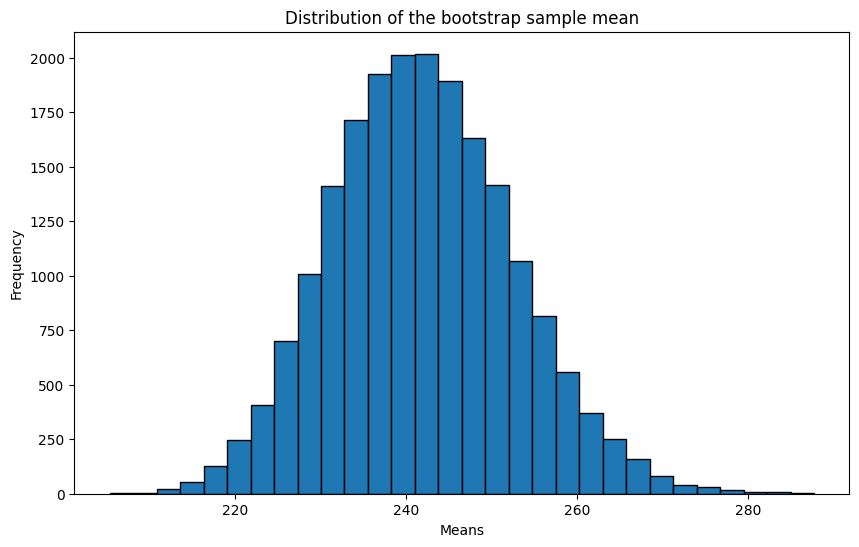

In [49]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Distribution of the bootstrap sample mean')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [50]:
boot_means["mean_price"].quantile([0.025,0.975])

0.025    222.174875
0.975    263.990437
Name: mean_price, dtype: float64